## Alexander Rees
## Andrew Lotocki
## Project Phase I
## DS 4420


# Scrape Data From CFB and Kaggle

In [1]:
!{sys.executable} -m pip install --upgrade kagglehub requests
!pip install pandas==2.2.2 numpy==1.26.4 requests==2.32.4 --force-reinstall
!pip install rapidfuzz

/bin/bash: line 1: {sys.executable}: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.1 MB

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.0 MB/s eta 0:00:00


In [1]:
import sys
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import re
import requests
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from rapidfuzz import process, fuzz
from keras.models import Model
from keras.layers import Dense, Input, SimpleRNN
from keras.optimizers import SGD
from keras.losses import binary_crossentropy
import numpy as np

In [2]:
combine_file = 'nfl_combine_2010_to_2023.csv'
CFB_API_KEY = "/UmsURW/Dk/PJwBD6CFzgiqHIIspHNuHME8H/1NeuQi+0HOutbRope/cQDHA1nVE"
headers = {"Authorization": f"Bearer {CFB_API_KEY}"}
years = list(range(2008, 2024))
combine_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, 'thomassshaw/nfl-combine-performance-dataset', path=combine_file)


def clean_name(name):
    if pd.isna(name):
        return None
    name = name.lower()
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\b(jr|sr|ii|iii|iv|v)\b", "", name)
    name = re.sub(r"\s+", " ", name)
    return name.strip()

position_map = {
    "wide receiver": "WR", "wr": "WR",
    "running back": "RB", "rb": "RB",
    "quarterback": "QB", "qb": "QB",
    "tight end": "TE", "te": "TE",
    "cornerback": "CB", "cb": "CB",
    "safety": "S", "s": "S",
    "linebacker": "LB", "lb": "LB",
    "defensive line": "DL", "dl": "DL",
    "defensive tackle": "DT", "dt": "DT",
    "defensive end": "DE", "de": "DE",
    "offensive line": "OL", "ol": "OL"
}

def clean_position(pos):
    if pd.isna(pos):
        return None
    pos = str(pos).lower().strip()
    return position_map.get(pos, pos.upper())

combine_df["clean_name"] = combine_df["Player"].apply(clean_name)
combine_df["position_clean"] = combine_df["Pos"].apply(clean_position)
combine_df["draft_year"] = combine_df["Year"]
cfb_list = []

for year in years:
    url = f"https://api.collegefootballdata.com/stats/player/season?year={year}"
    r = requests.get(url, headers=headers)
    data = r.json()

    if len(data) == 0:
        continue

    df = pd.DataFrame(data)
    df["clean_name"] = df["player"].apply(clean_name)
    df["position_clean"] = df["position"].apply(clean_position)
    df["season"] = year
    cfb_list.append(df)

cfb_df = pd.concat(cfb_list, ignore_index=True)
cfb_df["stat"] = cfb_df["stat"].astype(str)
cfb_df["stat"] = cfb_df["stat"].str.split("-").str[0]
cfb_df["stat"] = pd.to_numeric(cfb_df["stat"], errors="coerce")
cfb_df = cfb_df[cfb_df["stat"] < 10000]
last_season = cfb_df.groupby("clean_name")["season"].max().reset_index()
cfb_df = pd.merge(cfb_df, last_season, on=["clean_name", "season"], how="inner")

cfb_wide = cfb_df.pivot_table(
    index=["clean_name", "season", "position_clean"],
    columns=["category", "statType"],
    values="stat",
    aggfunc="sum"
).reset_index()

cfb_wide.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in cfb_wide.columns
]

cfb_wide.columns.name = None

cfb_by_position = {
    pos: group["clean_name"].dropna().values
    for pos, group in cfb_wide.groupby("position_clean")
}

all_cfb_names = cfb_wide["clean_name"].dropna().values


def match_with_position(name, pos, threshold=88):
    if pd.isna(name):
        return None, 0

    choices = cfb_by_position.get(pos)
    if choices is None or len(choices) == 0:
        choices = all_cfb_names

    match = process.extractOne(
        name,
        choices,
        scorer=fuzz.token_sort_ratio)

    if match is None:
        return None, 0

    matched_name, score, _ = match

    if score >= threshold:
        return matched_name, score
    else:
        return None, score


matches = combine_df.apply(lambda row: match_with_position(row["clean_name"], row["position_clean"]), axis=1)

combine_df["matched_name"] = matches.apply(lambda x: x[0])
combine_df["match_score"] = matches.apply(lambda x: x[1])

merged_df = pd.merge(
    combine_df,
    cfb_wide,
    left_on="matched_name",
    right_on="clean_name",
    how="left",
    suffixes=("", "_cfb")
)


merged_df = merged_df[(merged_df["season"] >= merged_df["Year"] - 2) & (merged_df["season"] <= merged_df["Year"])]

merged_df = merged_df.sort_values("match_score", ascending=False)
merged_df = merged_df.drop_duplicates(subset=["Player", "Year"])
merged_df.to_csv("data/player_data.csv", index=False)

print("Match rate:", combine_df["matched_name"].notna().mean())
print(merged_df.head())

100%|██████████| 355k/355k [00:00<00:00, 2.94MB/s]


Match rate: 0.5292132461506012
      Year           Player Pos          School Height  Weight  40yd  \
0     2010   Seyi Ajirotutu  WR    Fresno State    6-3   204.0  4.60   
3582  2020     Josiah Scott  CB  Michigan State    5-9   185.0  4.42   
3563  2020  Michael Pittman  WR             USC    6-4   223.0  4.52   
3564  2020       Troy Pride  CB      Notre Dame   5-11   193.0  4.40   
3565  2020     James Proche  WR             SMU   5-11   201.0   NaN   

      Vertical  Bench  Broad Jump  ...  receiving_LONG  receiving_REC  \
0         36.0   14.0       115.0  ...            46.0           49.0   
3582       NaN   17.0         NaN  ...             NaN            NaN   
3563      36.5   13.0       121.0  ...            77.0          101.0   
3564      35.5   13.0       119.0  ...             NaN            NaN   
3565      34.5   20.0         NaN  ...            52.0          111.0   

      receiving_TD  receiving_YDS  receiving_YPR rushing_CAR rushing_LONG  \
0              7.0  

# Seperating Cleaning and Scaling our Data

In [3]:
df = pd.read_csv("data/player_data.csv")
df = df.drop(columns=['season', 'Year', 'clean_name', 'Round', 'School', 'clean_name_cfb','match_score','position_clean_cfb', 'position_clean', 'matched_name'])
df["Height"] = (df["Height"].astype(str).str.split("-").apply(lambda x: int(x[0]) * 12 + int(x[1]) if len(x) == 2 else None))
df["Drafted"] = df["Drafted"].fillna(0).astype(int)
cols = [c for c in df.columns if c not in ["Player", "Pos"]]
df[cols] = df[cols].astype(float)

qb_data = df[df["Pos"] == "QB"]
qb_data = qb_data.dropna(axis=1, thresh=len(qb_data) * 0.5).reset_index(drop=True)
qb_data = qb_data.fillna(0)

rb_data = df[df["Pos"] == "RB"]
rb_data = rb_data.dropna(axis=1, thresh=len(rb_data) * 0.5).reset_index(drop=True)
rb_data = rb_data.fillna(0)

cb_data = df[df["Pos"] == "CB"]
cb_data = cb_data.dropna(axis=1, thresh=len(cb_data) * 0.5).reset_index(drop=True)
cb_data = cb_data.fillna(0)

wr_data = df[df["Pos"] == "WR"]
wr_data = wr_data.dropna(axis=1, thresh=len(wr_data) * 0.5).reset_index(drop=True)
wr_data = wr_data.fillna(0)

de_data = df[df["Pos"] == "DE"]
de_data = de_data.dropna(axis=1, thresh=len(de_data) * 0.5).reset_index(drop=True)
de_data = de_data.fillna(0)

qb_data.to_csv("data/qb_data.csv", index=False)
rb_data.to_csv("data/rb_data.csv", index=False)
cb_data.to_csv("data/cb_data.csv", index=False)
wr_data.to_csv("data/wr_data.csv", index=False)
de_data.to_csv("data/de_data.csv", index=False)

In [ ]:
print(qb_data.shape)
print(qb_data.columns)
qb_data.head()

In [ ]:
print(rb_data.shape)
print(rb_data.columns)
rb_data.head()

In [ ]:
print(cb_data.shape)
print(cb_data.columns)
cb_data.head()

In [ ]:
print(wr_data.shape)
print(wr_data.columns)
wr_data.head()

In [ ]:
print(de_data.shape)
print(de_data.columns)
de_data.head()

# Building Our MPL Draft Prediction Models

### QB Model

In [46]:
qb_df = pd.read_csv("data/qb_data.csv")
y_qb = qb_df["Drafted"].to_numpy()

X_qb = qb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_qb = MinMaxScaler().fit_transform(X_qb)

X_train, X_test, y_train, y_test = train_test_split(X_qb, y_qb, test_size=0.2, random_state=42)

In [47]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(64, activation='relu')(inpx)
hid_layer2 = Dense(32,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5444 - loss: 0.6817 
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5680 - loss: 0.6810 
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5740 - loss: 0.6803
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6805 - loss: 0.6796
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6627 - loss: 0.6784
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6331 - loss: 0.6774
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6272 - loss: 0.6765 
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6154 - loss: 0.6758
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6036 - loss: 0.6754
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6036 - loss: 0.6741
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6331 - loss: 0.6732 
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6095 - loss: 0.6721

In [48]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.679
accuracy= 0.581


In [49]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Actual      0   1
Predicted        
0          10  12
1           6  15


In [50]:
feature_cols = qb_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, abs(feature_importance)), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

Vertical: 0.3729
passing_YDS: 0.3362
rushing_TD: 0.3207
passing_YPA: 0.3160
40yd: 0.3057
rushing_CAR: 0.2986
rushing_YDS: 0.2808
3Cone: 0.2635
Shuttle: 0.2462
passing_PCT: 0.2238
rushing_LONG: 0.1944
Weight: 0.1644
passing_ATT: 0.1436
Broad Jump: 0.1104
passing_INT: 0.1076
passing_COMPLETIONS: 0.0706
passing_TD: 0.0436
draft_year: 0.0259
Height: 0.0056
rushing_YPC: 0.0025


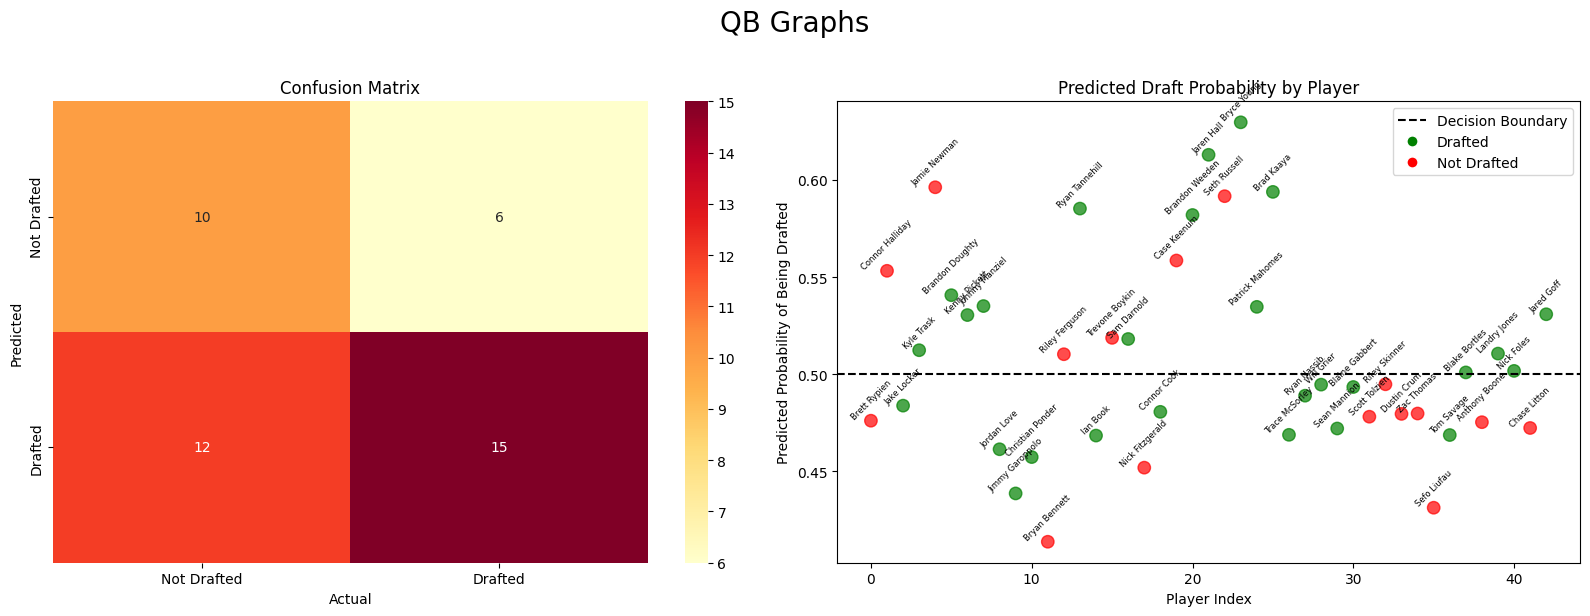

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('QB Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_qb, y_qb, qb_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### RB Model

In [52]:
rb_df = pd.read_csv("data/rb_data.csv")
y_rb = rb_df["Drafted"].to_numpy()

X_rb = rb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_rb = MinMaxScaler().fit_transform(X_rb)

X_train, X_test, y_train, y_test = train_test_split(X_rb, y_rb, test_size=0.2, random_state=42)

In [53]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6259 - loss: 0.6868  
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.6852 
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6370 - loss: 0.6832 
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6704 - loss: 0.6816 
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6593 - loss: 0.6801 
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6815 - loss: 0.6787 
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.6771 
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6741 - loss: 0.6755 
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.6744 
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.6727 
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6741 - loss: 0.6717 
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6741 - loss: 0.6701 


In [54]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.659
accuracy= 0.618


In [55]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Actual      0   1
Predicted        
0           8  13
1          13  34


In [56]:
feature_cols = rb_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, abs(feature_importance)), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

Weight: 0.2068
receiving_YDS: 0.1890
rushing_TD: 0.1854
Broad Jump: 0.1707
rushing_YDS: 0.1476
Height: 0.1434
receiving_LONG: 0.1355
rushing_YPC: 0.1345
Shuttle: 0.1313
receiving_YPR: 0.1186
receiving_TD: 0.1184
Bench: 0.1073
40yd: 0.0970
Vertical: 0.0954
draft_year: 0.0891
rushing_LONG: 0.0727
receiving_REC: 0.0561
rushing_CAR: 0.0534
3Cone: 0.0477


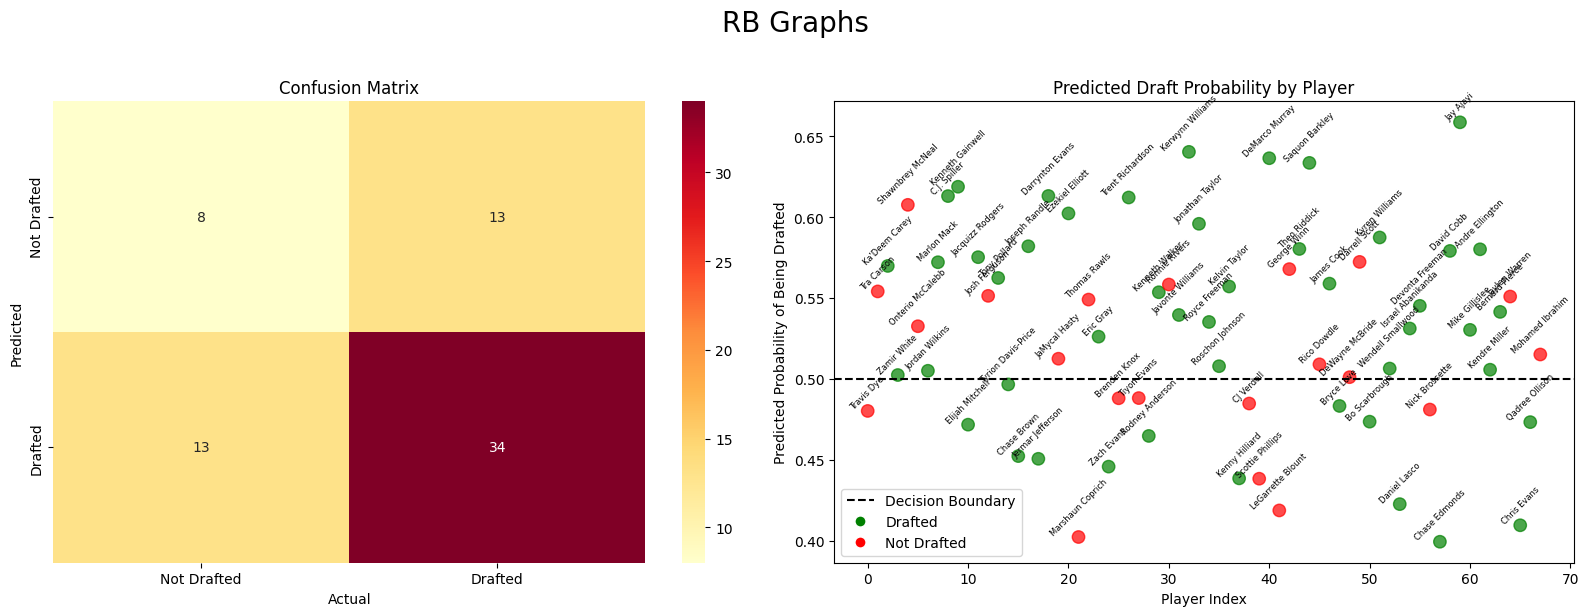

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RB Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_rb, y_rb, rb_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### WR Model

In [58]:
wr_df = pd.read_csv("data/wr_data.csv")
y_wr = wr_df["Drafted"].to_numpy()

X_wr = wr_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_wr = MinMaxScaler().fit_transform(X_wr)

X_train, X_test, y_train, y_test = train_test_split(X_wr, y_wr, test_size=0.2, random_state=42)

In [59]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4193 - loss: 0.6954  
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4350 - loss: 0.6928 
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4664 - loss: 0.6909 
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5112 - loss: 0.6893 
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5717 - loss: 0.6879 
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6009 - loss: 0.6865 
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6143 - loss: 0.6852 
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6300 - loss: 0.6843 
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6457 - loss: 0.6831 
Epoch 10/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6592 - loss: 0.6822 
Epoch 11/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6525 - loss: 0.6814 
Epoch 12/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [60]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.666
accuracy= 0.616


In [61]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Actual      0   1
Predicted        
0          25  23
1          20  44


In [63]:
feature_cols = wr_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, abs(feature_importance)), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

receiving_REC: 0.2221
rushing_YDS: 0.2175
receiving_YPR: 0.2110
Broad Jump: 0.2093
rushing_CAR: 0.1705
receiving_TD: 0.1591
Shuttle: 0.1575
Weight: 0.1549
Bench: 0.1360
Height: 0.1243
rushing_LONG: 0.1159
rushing_YPC: 0.1067
Vertical: 0.0887
rushing_TD: 0.0779
3Cone: 0.0728
draft_year: 0.0365
receiving_YDS: 0.0302
receiving_LONG: 0.0264
40yd: 0.0131


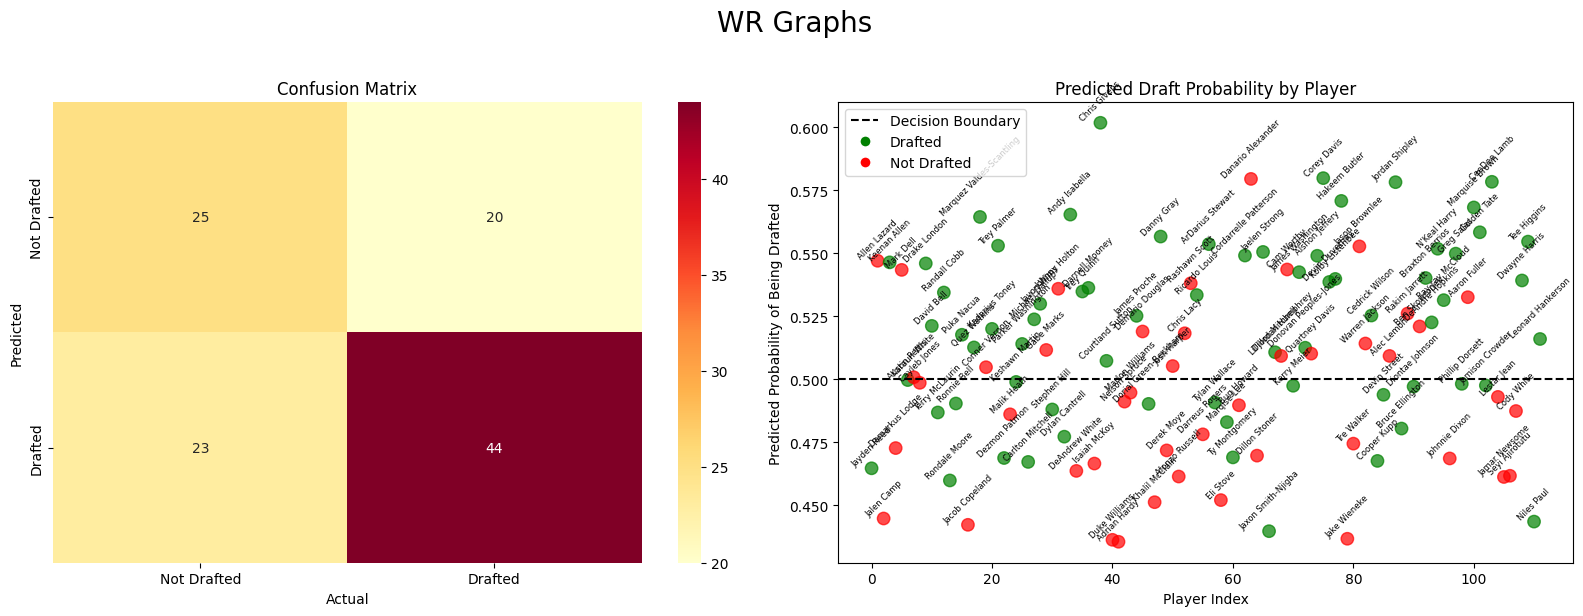

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('WR Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_wr, y_wr, wr_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### CB Model

In [65]:
cb_df = pd.read_csv("data/cb_data.csv")
y_cb = cb_df["Drafted"].to_numpy()

X_cb = cb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_cb = MinMaxScaler().fit_transform(X_cb)

X_train, X_test, y_train, y_test = train_test_split(X_cb, y_cb, test_size=0.2, random_state=42)

In [66]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7262 - loss: 0.6983  
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7262 - loss: 0.6970 
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7262 - loss: 0.6953 
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7262 - loss: 0.6943 
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7202 - loss: 0.6932 
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7440 - loss: 0.6919 
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7440 - loss: 0.6911 
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7262 - loss: 0.6904 
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7321 - loss: 0.6890 
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7321 - loss: 0.6883 
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7202 - loss: 0.6874 
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7262 - loss: 0.6865 


In [67]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.662
accuracy= 0.791


In [68]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Actual     0   1
Predicted       
0          2   1
1          8  32


In [69]:
feature_cols = cb_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, abs(feature_importance)), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

defensive_TOT: 0.2073
Bench: 0.1969
defensive_SACKS: 0.1753
interceptions_YDS: 0.1727
Vertical: 0.1656
interceptions_INT: 0.1652
Weight: 0.1506
interceptions_AVG: 0.1324
Height: 0.1190
interceptions_TD: 0.1186
Shuttle: 0.1026
40yd: 0.0749
3Cone: 0.0677
Broad Jump: 0.0677
defensive_QB HUR: 0.0343
defensive_PD: 0.0312
defensive_TFL: 0.0303
defensive_SOLO: 0.0253
draft_year: 0.0112
defensive_TD: 0.0073


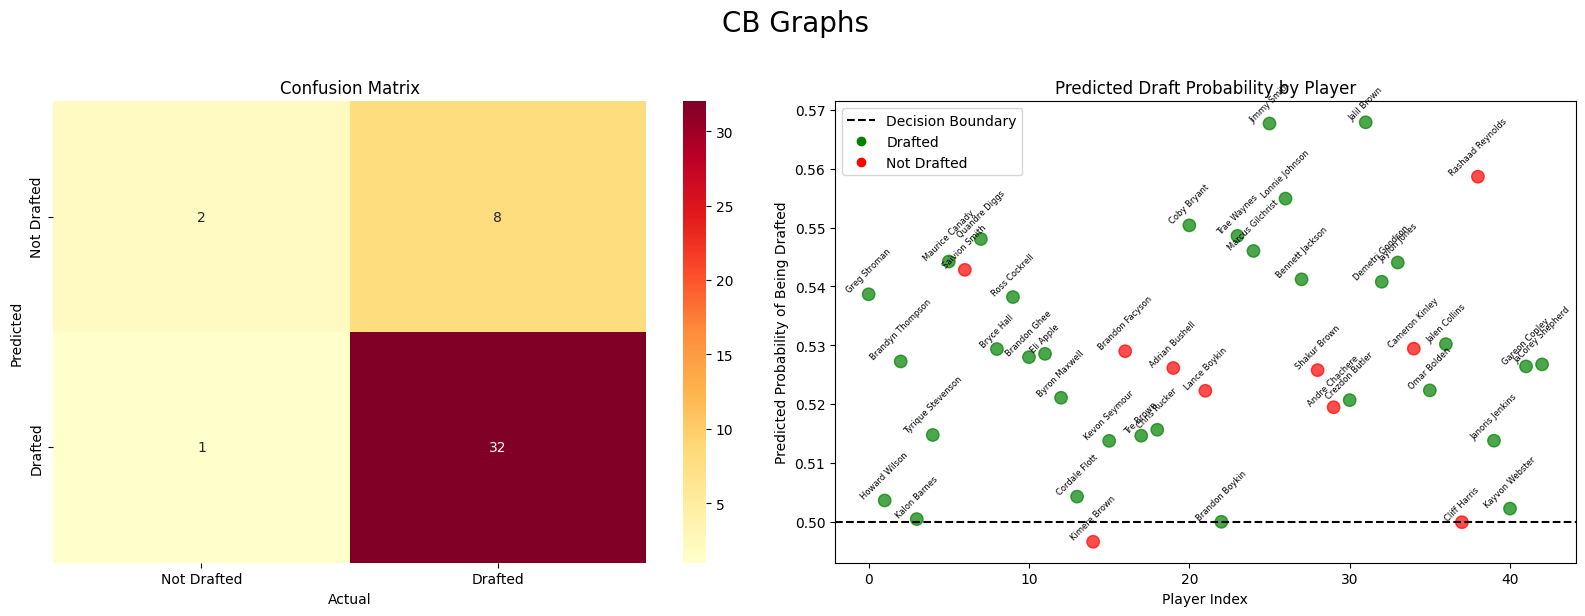

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CB Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_cb, y_cb, cb_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### DE Model

In [71]:
de_df = pd.read_csv("data/de_data.csv")
y_de = de_df["Drafted"].to_numpy()

X_de = de_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_de = MinMaxScaler().fit_transform(X_de)

X_train, X_test, y_train, y_test = train_test_split(X_de, y_de, test_size=0.2, random_state=42)

In [72]:
inpx = Input(shape=(X_train.shape[1], 1))
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7143 - loss: 0.6983 
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7143 - loss: 0.6967
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7143 - loss: 0.6952
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7143 - loss: 0.6937
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7143 - loss: 0.6924
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7143 - loss: 0.6911
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7143 - loss: 0.6899
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7143 - loss: 0.6889
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7143 - loss: 0.6892
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7143 - loss: 0.6875
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7143 - loss: 0.6865
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7143 - loss: 0

In [73]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.671
accuracy= 0.733


In [74]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Actual     0   1
Predicted       
0          0   1
1          3  11


In [75]:
feature_cols = de_df.drop(columns=["Player", "Pos", "Drafted", "Pick"]).columns.tolist()
dense_weights = model.get_layer(index=3).get_weights()[0]
feature_importance = dense_weights.mean(axis=1)

for name, score in sorted(zip(feature_cols, abs(feature_importance)), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

Shuttle: 0.1958
defensive_SACKS: 0.1955
3Cone: 0.1938
defensive_TD: 0.1772
40yd: 0.1692
defensive_SOLO: 0.1597
Vertical: 0.1513
defensive_TFL: 0.1463
defensive_PD: 0.1311
defensive_TOT: 0.1020
defensive_QB HUR: 0.1009
Bench: 0.1009
draft_year: 0.0623
Weight: 0.0513
Height: 0.0479
Broad Jump: 0.0236


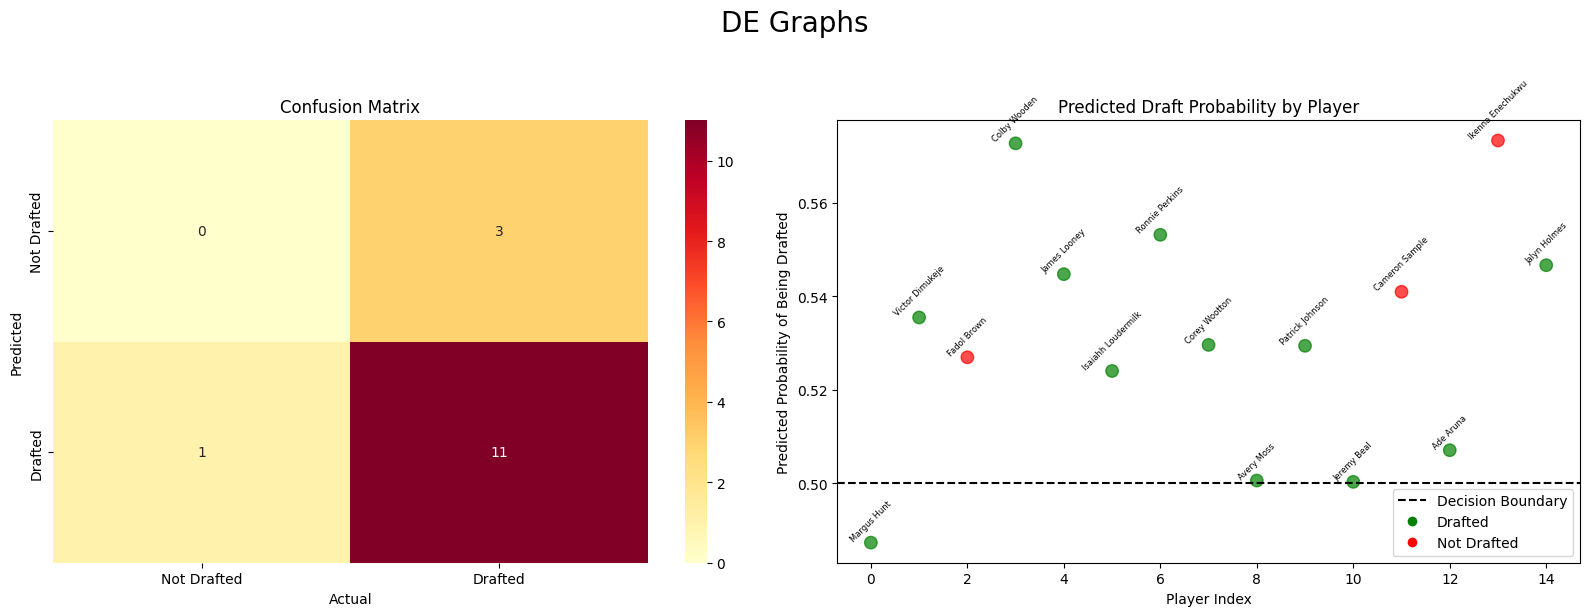

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DE Graphs', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

_, X_test_raw, _, y_test_raw, _, names_test = train_test_split(
    X_de, y_de, de_df["Player"].values, test_size=0.2, random_state=42
)

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    axes[1].annotate(name, (i, preds_flat[i]), fontsize=6, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()